### Always Run

In [23]:
### import necessary libraries
import numpy as np
import pandas as pd
import csv
from sklearn.preprocessing import LabelEncoder
from matplotlib.animation import FuncAnimation
import scanpy as sc
import scanpy as sc
import matplotlib.pyplot as plt
import anndata as ad
from mpl_toolkits.axes_grid1 import make_axes_locatable
import seaborn as sns
import os
from scipy import stats
from scipy.optimize import curve_fit
import math

from module.config_local import dir_raw, dir_processed, dir_main, sample_name_import

In [24]:
### HC ###

name_dir = 'all-samples-C0'

samples_ids = sample_name_import(name_dir)

# Animation

In [25]:
adata = sc.read_h5ad(f'{dir_processed}/h5ad/{name_dir}/{name_dir}_final.h5ad.gz')
adata = adata[(adata.obs['sample']=='3159-2')]

adata.obs['umap-3'] = adata.obsm['X_umap'][:, 0]
adata.obs['umap-4'] = adata.obsm['X_umap'][:, 1]

adata.obs['x_centroid'].astype('float')
adata.obs['y_centroid'].astype('float')
adata.obs['y_centroid'].astype('float')
adata.obs['umap-1'].astype('float')
adata.obs['umap-2'].astype('float')

adata.obs['umap-1'] = adata.obs['umap-1'] + abs(adata.obs['umap-1'].min())
adata.obs['umap-2'] = adata.obs['umap-2'] + abs(adata.obs['umap-2'].min())
adata.obs['umap-1'] = adata.obs['umap-1'] / adata.obs['umap-1'].max()
adata.obs['umap-2'] = adata.obs['umap-2'] / adata.obs['umap-2'].max()
adata.obs['x_centroid'] = adata.obs['x_centroid'] / adata.obs['x_centroid'].max()
adata.obs['y_centroid'] = adata.obs['y_centroid'] / adata.obs['y_centroid'].max()



# Extract data
x1, y1 = adata.obs['x_centroid'].values, adata.obs['y_centroid'].values
x2, y2 = adata.obs['umap-1'].values, adata.obs['umap-2'].values

unique_clusters = adata.obs['cell_type_newnum_final'].unique()
colors = plt.cm.tab10(unique_clusters / len(unique_clusters))
# Create a dictionary to map clusters to colors
cluster_to_color = {cluster: color for cluster, color in zip(unique_clusters, colors)}
point_colors = [cluster_to_color[cluster] for cluster in clusters]



# Set up the figure and axis
fig, ax = plt.subplots()
scat = ax.scatter(adata.obs['umap-3'].values, adata.obs['umap-4'].values, c=point_colors, s = 0.01)

# # Function to interpolate points between two sets of coordinates
# def interpolate_points(x1, y1, x2, y2, t):
#     return (1 - t) * x1 + t * x2, (1 - t) * y1 + t * y2

# # Animation update function
# def update(frame):
#     t = frame / n_frames  # Normalize frame index to range [0, 1]
#     new_x, new_y = interpolate_points(adata.obs['x_centroid'].values, adata.obs['y_centroid'].values,
#                                        adata.obs['umap-1'].values, adata.obs['umap-2'].values, t)
#     scat.set_offsets(np.c_[new_x, new_y])
#     return scat,

# # Number of frames for the animation
# n_frames = 100

# # Create the animation
# ani = FuncAnimation(fig, update, frames=n_frames, interval=50, blit=True)

# Display the animation
plt.show()

# To save the animation as a file (e.g., .mp4), uncomment the line below:
# ani.save('scatter_transformation.gif', writer='Pillow')


C:\Users\hcall\AppData\Local\Temp\ipykernel_2084\252471720.py:4: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['umap-3'] = adata.obsm['X_umap'][:, 0]


KeyError: 0.0

In [ ]:
colors

(np.float64(0.12156862745098039),
 np.float64(0.4666666666666667),
 np.float64(0.7058823529411765),
 np.float64(1.0))

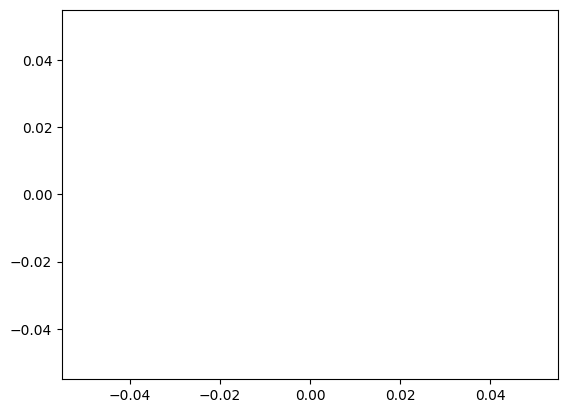

In [ ]:
#Reverse
# Extract data
x2, y2 = adata.obs['x_centroid'].values, adata.obs['y_centroid'].values
x1, y1 = adata.obs['umap-1'].values, adata.obs['umap-2'].values

clusters = adata.obs['cell_type_newnum_final'].values
# Determine unique clusters for coloring
unique_clusters = np.unique(clusters)
colors = plt.cm.tab10(len(unique_clusters))
# Create a dictionary to map clusters to colors
cluster_to_color = {cluster: color for cluster, color in zip(unique_clusters, colors)}
point_colors = [cluster_to_color[cluster] for cluster in clusters]



# Set up the figure and axis
fig, ax = plt.subplots()
scat = ax.scatter(adata.obs['umap-1'].values, adata.obs['umap-2'].values, c=point_colors, s = 0.01)

# Function to interpolate points between two sets of coordinates
def interpolate_points(x1, y1, x2, y2, t):
    return (1 - t) * x1 + t * x2, (1 - t) * y1 + t * y2

# Animation update function
def update(frame):
    t = frame / n_frames  # Normalize frame index to range [0, 1]
    new_x, new_y = interpolate_points(adata.obs['umap-1'].values, adata.obs['umap-2'].values, 
                                      adata.obs['x_centroid'].values, adata.obs['y_centroid'].values, t)
    scat.set_offsets(np.c_[new_x, new_y])
    return scat,

# Number of frames for the animation
n_frames = 100

# Create the animation
ani = FuncAnimation(fig, update, frames=n_frames, interval=50, blit=True)

# Display the animation
plt.show()

# To save the animation as a file (e.g., .mp4), uncomment the line below:
# ani.save('scatter_transformation_reverse.gif', writer='Pillow')


In [ ]:
adata = sc.read_h5ad(f'{dir_processed}/h5ad/{name_dir}/{name_dir}_MMC_Banksy_annotated.h5ad')

In [ ]:
from sklearn.preprocessing import LabelEncoder
from matplotlib.animation import FuncAnimation
import scanpy as sc

adata = sc.read_h5ad(f'{dir_processed}/h5ad/{name_dir}/{name_dir}_MMC_Banksy_annotated.h5ad')
adata = adata[(adata.obs['sample']=='3161-1')]
adata = adata[(adata.obs['cell_type_newnum']==0)|(adata.obs['cell_type_newnum'] == 1)]


adata.obs['x_centroid'].astype('float')
adata.obs['y_centroid'].astype('float')
adata.obs['y_centroid'].astype('float')
adata.obs['umap-1'].astype('float')
adata.obs['umap-2'].astype('float')

adata.obs['umap-1'] = adata.obs['umap-1'] + abs(adata.obs['umap-1'].min())
adata.obs['umap-2'] = adata.obs['umap-2'] + abs(adata.obs['umap-2'].min())
adata.obs['umap-1'] = (adata.obs['umap-1'] / adata.obs['umap-1'].max()) + 1
adata.obs['umap-2'] = adata.obs['umap-2'] / adata.obs['umap-2'].max()
adata.obs['x_centroid'] = adata.obs['x_centroid'] / adata.obs['x_centroid'].max()
adata.obs['y_centroid'] = adata.obs['y_centroid'] / adata.obs['y_centroid'].max()

In [ ]:
adata.obs['sample'].unique()

In [ ]:
# from sklearn.preprocessing import LabelEncoder
# from matplotlib.animation import FuncAnimation
# import scanpy as sc

adata = sc.read_h5ad(f'{dir_processed}/h5ad/{name_dir}/{name_dir}_MMC_Banksy_annotated.h5ad')
# # adata = adata[(adata.obs['sample']=='3161-1')]


# adata.obs['x_centroid'].astype('float')
# adata.obs['y_centroid'].astype('float')
# adata.obs['y_centroid'].astype('float')
# adata.obs['umap-1'].astype('float')
# adata.obs['umap-2'].astype('float')

# adata.obs['umap-1'] = adata.obs['umap-1'] + abs(adata.obs['umap-1'].min())
# adata.obs['umap-2'] = adata.obs['umap-2'] + abs(adata.obs['umap-2'].min())
# adata.obs['umap-1'] = (adata.obs['umap-1'] / adata.obs['umap-1'].max()) + 1
# adata.obs['umap-2'] = adata.obs['umap-2'] / adata.obs['umap-2'].max()
# adata.obs['x_centroid'] = adata.obs['x_centroid'] / adata.obs['x_centroid'].max()
# adata.obs['y_centroid'] = adata.obs['y_centroid'] / adata.obs['y_centroid'].max()
# adata.obs.loc[adata.obs['sample'] == '3159-2', 'x_centroid'] = adata.obs.loc[adata.obs['sample'] == '3159-2', 'x_centroid']
# adata.obs.loc[adata.obs['sample'] == '3159-2', 'y_centroid'] = adata.obs.loc[adata.obs['sample'] == '3159-2', 'y_centroid']
# adata.obs.loc[adata.obs['sample'] == '3161-1', 'x_centroid'] = adata.obs.loc[adata.obs['sample'] == '3161-1', 'x_centroid'] + 2
# adata.obs.loc[adata.obs['sample'] == '3161-1', 'y_centroid'] = adata.obs.loc[adata.obs['sample'] == '3161-1', 'y_centroid']

# Extract data
clusters = adata.obs['cell_type_newnum'].values
# Determine unique clusters for coloring
unique_clusters = np.unique(clusters)
colors = plt.cm.tab10(unique_clusters / max(unique_clusters))
# Create a dictionary to map clusters to colors
cluster_to_color = {cluster: color for cluster, color in zip(unique_clusters, colors)}
point_colors = [cluster_to_color[cluster] for cluster in clusters]

# Set up the figure and axis
fig, ax = plt.subplots(figsize=(24, 7))
scat = ax.scatter(adata.obs['umap-1'].values, adata.obs['umap-2'].values, c=point_colors, s = 0.01)
plt.xlim(0, 3)
plt.ylim(-0.2, 1.2)

x2, y2 = adata.obs['x_centroid'].values, adata.obs['y_centroid'].values
x1, y1 = adata.obs['umap-1'].values, adata.obs['umap-2'].values

# Function to interpolate points between two sets of coordinates
def interpolate_points(x1, y1, x2, y2, t):
    
    return (1 - t) * x1 + t * x2, (1 - t) * y1 + t * y2

# Animation update function
def update(frame):
    t = frame / n_frames  # Normalize frame index to range [0, 1]
    new_x, new_y = interpolate_points(adata.obs['umap-1'].values, adata.obs['umap-2'].values, 
                                      adata.obs['x_centroid'].values, adata.obs['y_centroid'].values, t)
    scat.set_offsets(np.c_[new_x, new_y])
    return scat,

# Number of frames for the animation
n_frames =30

# Create the animation
ani = FuncAnimation(fig, update, frames=n_frames, interval=10, blit=True)

# Display the animation
plt.show()

# To save the animation as a file (e.g., .mp4), uncomment the line below:
ani.save('scatter_transformation_reverse3.gif', writer='Pillow')

In [ ]:
# adata = sc.read_h5ad(f'{dir_processed}/h5ad/{name_dir}/{name_dir}_MMC_Banksy_annotated.h5ad')
adata.obsm

In [ ]:
### DATA PREPARATION

from sklearn.preprocessing import LabelEncoder
from matplotlib.animation import FuncAnimation
import scanpy as sc

adata = sc.read_h5ad(f'{dir_processed}/h5ad/{name_dir}/{name_dir}_final.h5ad.gz')

adata.obs['umap-1'] = adata.obsm['reduced_pc_20_umap'][:, 0]
adata.obs['umap-2'] = adata.obsm['reduced_pc_20_umap'][:, 1]

adata.obs['x_centroid'].astype('float')
adata.obs['y_centroid'].astype('float')
adata.obs['y_centroid'].astype('float')
adata.obs['umap-1'].astype('float')
adata.obs['umap-2'].astype('float')

adata.obs['umap-1'] = adata.obs['umap-1'] + abs(adata.obs['umap-1'].min())
adata.obs['umap-2'] = adata.obs['umap-2'] + abs(adata.obs['umap-2'].min())
adata.obs['umap-1'] = ((adata.obs['umap-1'] / adata.obs['umap-1'].max()) * 1.5) +0.25
adata.obs['umap-2'] = ((adata.obs['umap-2'] / adata.obs['umap-2'].max()) * 1.5) + 3
adata.obs['x_centroid'] = adata.obs['x_centroid'] / adata.obs['x_centroid'].max()
adata.obs['y_centroid'] = adata.obs['y_centroid'] / adata.obs['y_centroid'].max()
adata.obs.loc[adata.obs['sample'] == '3159-1', 'x_centroid'] = adata.obs.loc[adata.obs['sample'] == '3159-1', 'x_centroid']
adata.obs.loc[adata.obs['sample'] == '3159-1', 'y_centroid'] = adata.obs.loc[adata.obs['sample'] == '3159-1', 'y_centroid'] + 2
adata.obs.loc[adata.obs['sample'] == '3160-1', 'x_centroid'] = adata.obs.loc[adata.obs['sample'] == '3160-1', 'x_centroid']
adata.obs.loc[adata.obs['sample'] == '3160-1', 'y_centroid'] = adata.obs.loc[adata.obs['sample'] == '3160-1', 'y_centroid'] + 1
adata.obs.loc[adata.obs['sample'] == '3160-2', 'x_centroid'] = adata.obs.loc[adata.obs['sample'] == '3160-2', 'x_centroid']
adata.obs.loc[adata.obs['sample'] == '3160-2', 'y_centroid'] = adata.obs.loc[adata.obs['sample'] == '3160-2', 'y_centroid']
adata.obs.loc[adata.obs['sample'] == '2670-1', 'x_centroid'] = adata.obs.loc[adata.obs['sample'] == '2670-1', 'x_centroid'] +1
adata.obs.loc[adata.obs['sample'] == '2670-1', 'y_centroid'] = adata.obs.loc[adata.obs['sample'] == '2670-1', 'y_centroid'] +2
adata.obs.loc[adata.obs['sample'] == '2505-1', 'x_centroid'] = adata.obs.loc[adata.obs['sample'] == '2505-1', 'x_centroid'] +1
adata.obs.loc[adata.obs['sample'] == '2505-1', 'y_centroid'] = adata.obs.loc[adata.obs['sample'] == '2505-1', 'y_centroid'] +1
adata.obs.loc[adata.obs['sample'] == '2505-2', 'x_centroid'] = adata.obs.loc[adata.obs['sample'] == '2505-2', 'x_centroid'] +1
adata.obs.loc[adata.obs['sample'] == '2505-2', 'y_centroid'] = adata.obs.loc[adata.obs['sample'] == '2505-2', 'y_centroid']

adata.obs.loc[adata.obs['sample'] == '3159-2', 'x_centroid'] = adata.obs.loc[adata.obs['sample'] == '3159-2', 'x_centroid']
adata.obs.loc[adata.obs['sample'] == '3159-2', 'y_centroid'] = adata.obs.loc[adata.obs['sample'] == '3159-2', 'y_centroid'] + 2
adata.obs.loc[adata.obs['sample'] == '3161-1', 'x_centroid'] = adata.obs.loc[adata.obs['sample'] == '3161-1', 'x_centroid']
adata.obs.loc[adata.obs['sample'] == '3161-1', 'y_centroid'] = adata.obs.loc[adata.obs['sample'] == '3161-1', 'y_centroid'] + 1

# Extract data
clusters = adata.obs['cell_type_newnum_final'].astype(float)
# Determine unique clusters for coloring
unique_clusters = np.unique(clusters)
colors = plt.cm.tab20b(unique_clusters / max(unique_clusters))
# Create a dictionary to map clusters to colors
cluster_to_color = {cluster: color for cluster, color in zip(unique_clusters, colors)}
point_colors = [cluster_to_color[cluster] for cluster in clusters]


In [ ]:
adata.obs['cell_type_newnum_final'].unique()

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
       51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61])

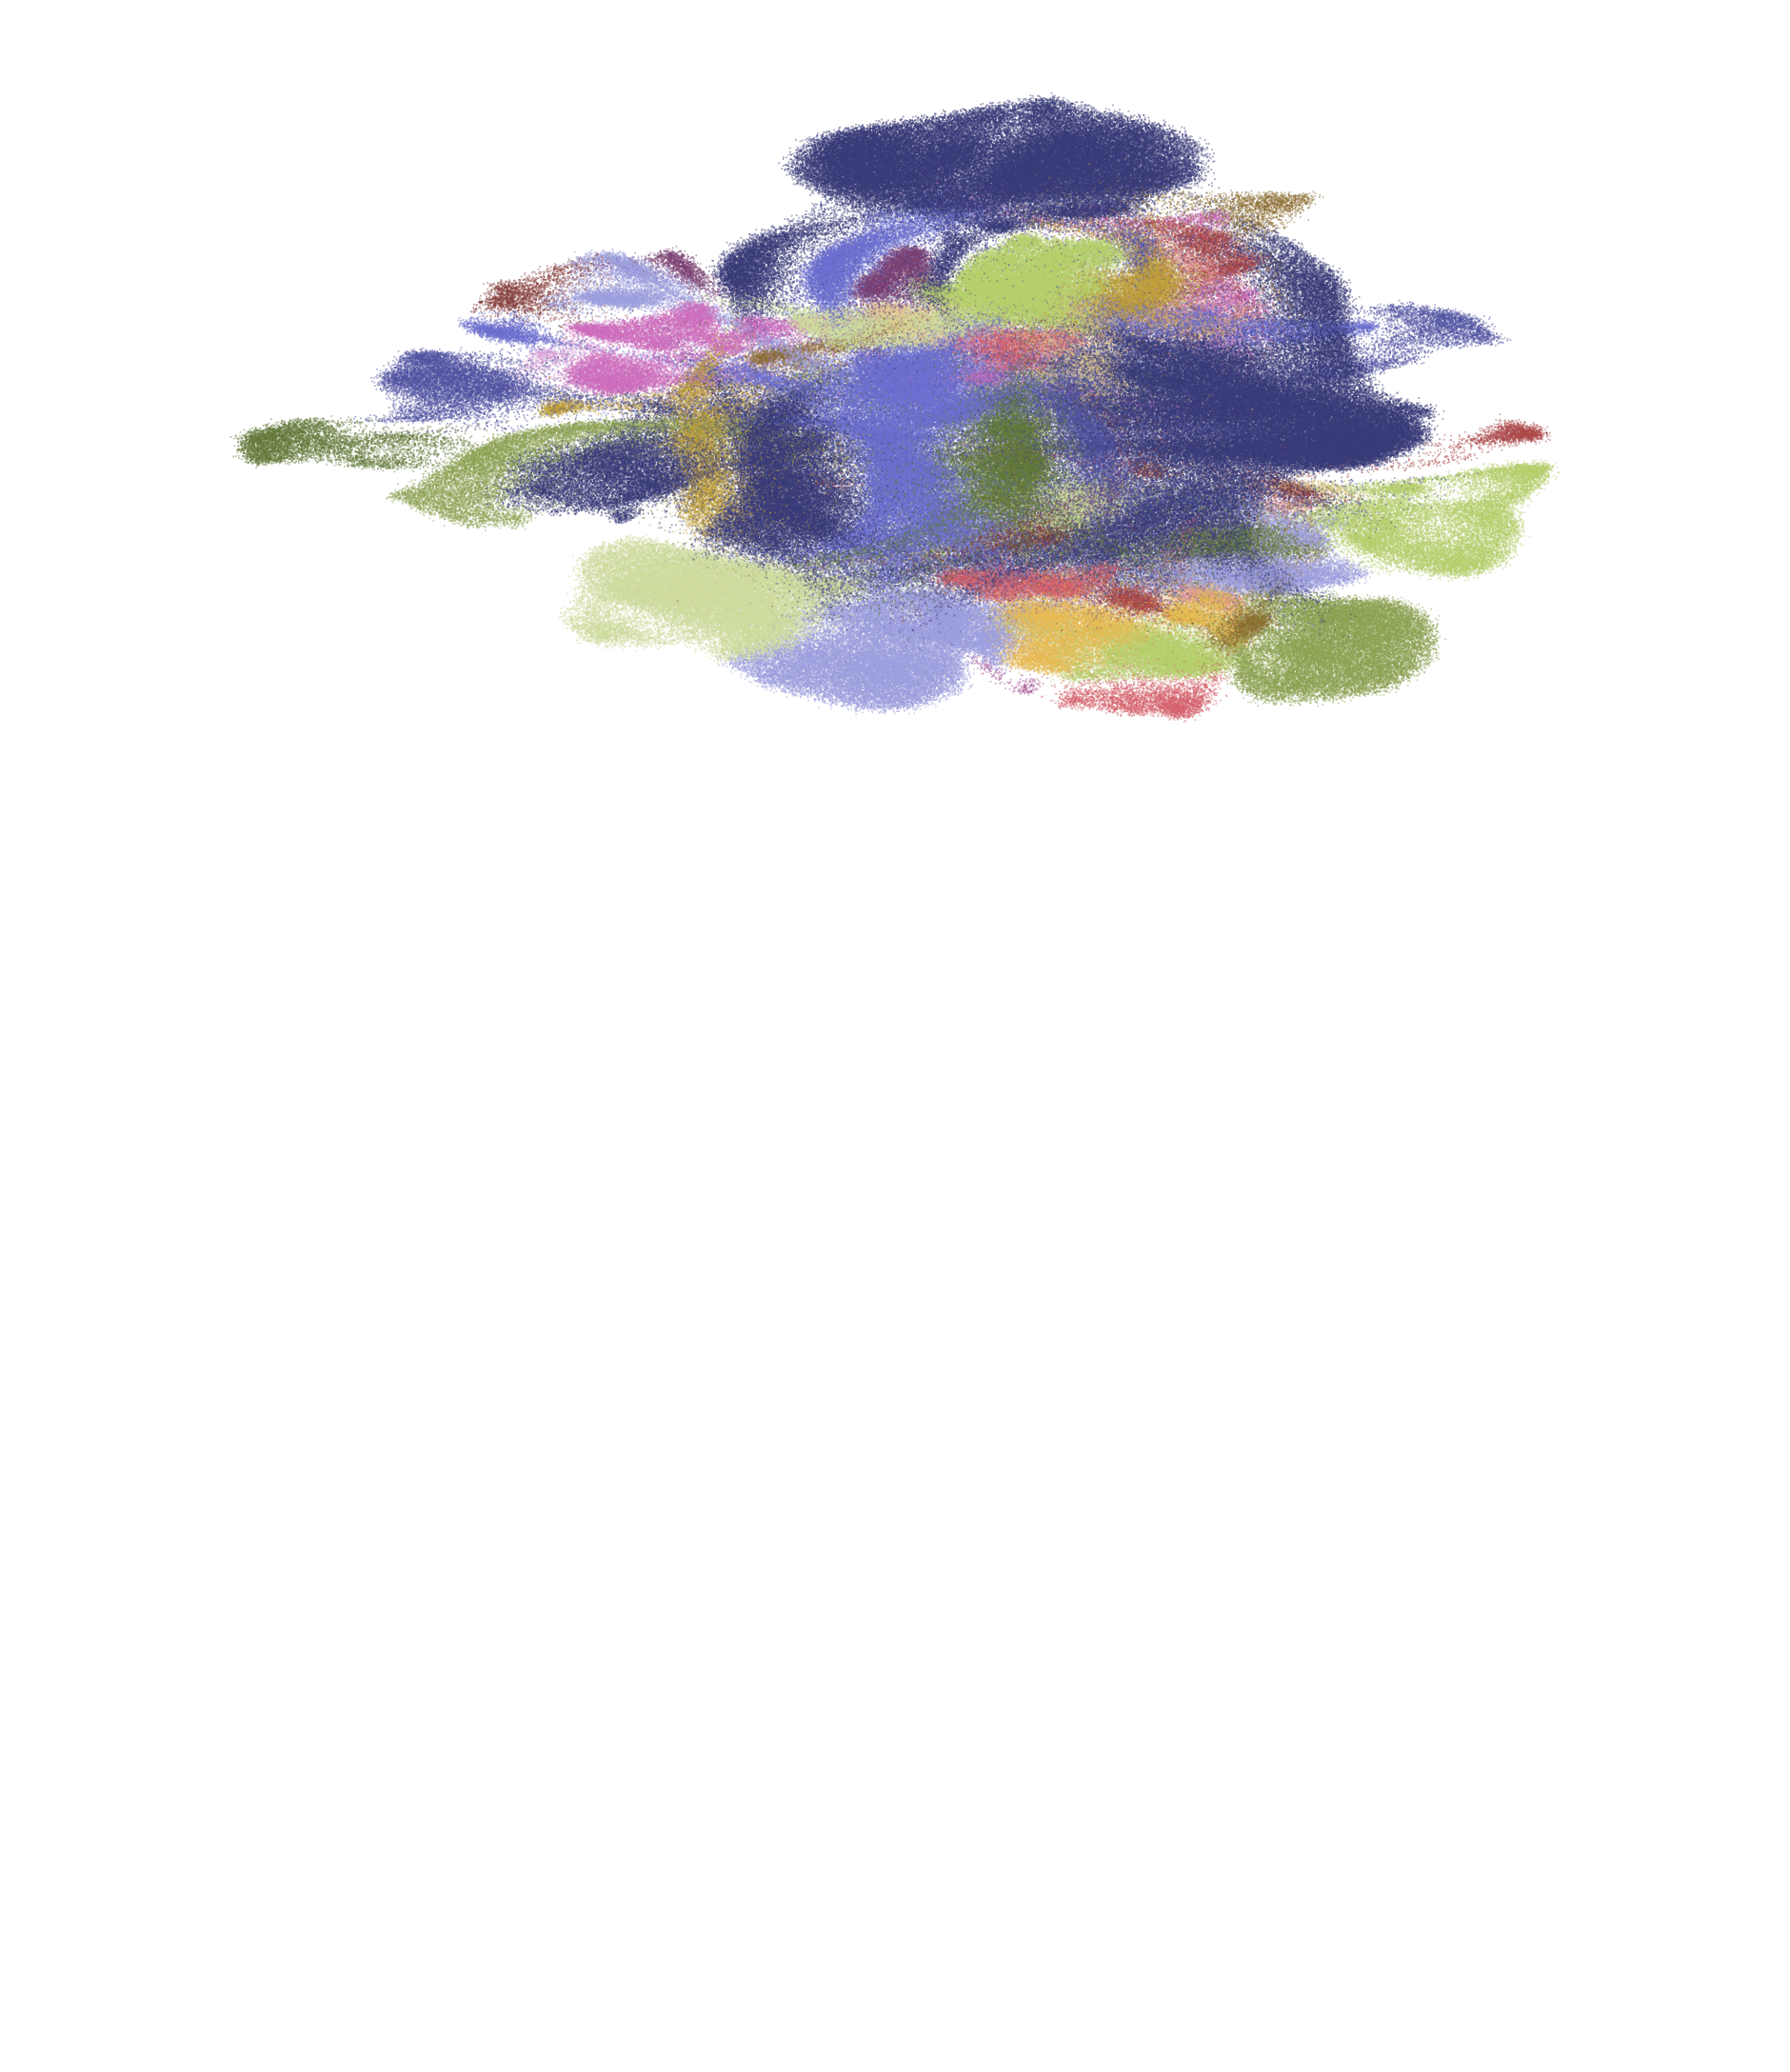

In [ ]:
fig, ax = plt.subplots(figsize=(24, 28))
scat = ax.scatter(adata.obs['umap-1'].values, adata.obs['umap-2'].values, c=point_colors,
                  s = 0.05)
ax.axis('off')
plt.xlim(0, 2)
plt.ylim(-0.2, 4.7)
# plt.savefig('umap-run1.png')

In [ ]:
fig, ax = plt.subplots(figsize=(24, 28))
scat = ax.scatter(adata.obs['x_centroid'].values, adata.obs['y_centroid'].values, c=point_colors, s = 0.05)
ax.axis('off')
plt.xlim(0, 2)
plt.ylim(-0.2, 4.7)
plt.savefig('sections-run1.png')

In [ ]:
### PLOT AND ANIM

# Set up the figure and axis
fig, ax = plt.subplots(figsize=(24, 28))
scat = ax.scatter(adata.obs['umap-1'].values, adata.obs['umap-2'].values, c=point_colors, s = 0.05)
ax.axis('off')
plt.xlim(0, 2)
plt.ylim(-0.2, 4.7)

x2, y2 = adata.obs['x_centroid'].values, adata.obs['y_centroid'].values
x1, y1 = adata.obs['umap-1'].values, adata.obs['umap-2'].values

# Function to interpolate points between two sets of coordinates
def interpolate_points(x1, y1, x2, y2, t):
    
    return (1 - t) * x1 + t * x2, (1 - t) * y1 + t * y2

# Animation update function
def update(frame):
    t = frame / n_frames  # Normalize frame index to range [0, 1]
    new_x, new_y = interpolate_points(adata.obs['umap-1'].values, adata.obs['umap-2'].values, 
                                      adata.obs['x_centroid'].values, adata.obs['y_centroid'].values, t)
    scat.set_offsets(np.c_[new_x, new_y])
    return scat,

# Number of frames for the animation
n_frames =25

# Create the animation
ani = FuncAnimation(fig, update, frames=n_frames, interval=10, blit=True)

# Display the animation
plt.show()

# To save the animation as a file (e.g., .mp4), uncomment the line below:
ani.save('scatter_transformation_run1-bis.gif', writer='Pillow')